This notebook was inspired by this this [Pythonic Excursions notebook](https://aegis4048.github.io/mutiple_linear_regression_and_visualization_in_python)

# Packages

In [1]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import r2_score, root_mean_squared_error
import sklearn

import sys
sys.path.append("../utils/")
# from util_selector import format_time
from util_preprocessing import check_or_create_directory
# from util_postprocessing import *
# from util_models import *

RANDOM_STATE = 11

sklearn.random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# Loading Data 

In [2]:
df = pd.read_excel("./inputs/For Thesis - Chap6 - 2.xlsx", sheet_name="For Thesis - Chap6")
print(df.shape)
df

(33, 11)


,Reference,Type,Year,Title,Venue,#Datasets,#Baselines,#NewMethods,WinRate,SuccessRate,Notes
0,\citet{battiti_using_1994},J,1994,Using Mutual Information for Selecting Feature...,IEEE Transactions on Neural Networks [and Lear...,2,2,1,100,-,- 1st mRMR (MIFS) - 1 hyperparameter beta - 3 ...
1,\citet{kwak_input_2002},J,2002,Input feature selection for classification pro...,IEEE Transactions on Neural Networks [and Lear...,2,4,2,100,50,- Not Outperform all competitions? - MIFS incl...
2,\citet{peng_feature_2005},J,2005,Feature selection based on mutual information ...,IEEE Transactions on Pattern Analysis and Mach...,4,1,1,100,-,- Include NCI[9] dataset - Hybrid with Forward...
3,\citet{ding_minimum_2005},J,2005,MINIMUM REDUNDANCY FEATURE SELECTION FROM MICR...,Journal of Bioinformatics and Computational Bi...,6,2,4,100,-,"- Include NCI[9] - Introduced mRMR_MID, mRMR_M..."
4,\citet{lin_conditional_2006},C,2006,Conditional Infomax Learning: An Integrated Fr...,9th European Conference on Computer Vision,3,4,2,100,-,NaN
5,\citet{mandal_improved_2013},J,2013,An Improved Minimum Redundancy Maximum Relevan...,Procedia Technology,4,2,1,100,-,- Both formulations of mRMR with MI as baselin...
6,\citet{yang_minimal-redundancy-maximal-relevan...,C,2013,Minimal-redundancy-maximal-relevance feature s...,IEEE Symposium on Computational Intelligence i...,5,1,2,80,100,"- 3 rel. est. with k in {20,40,60, 80, 100, Al..."
7,\citet{zhang_compact_2014},C,2014,Compact Representation for Image Classificatio...,IEEE Conference on Computer Vision and Pattern...,4,2,1,50,-,- Introduced 2 baselines but used one of them ...
8,\citet{bennasar_feature_2015},J,2015,Feature selection using Joint Mutual Informati...,Expert Systems with Applications,11,5,2,63.6,-,- 2 FS methods - Information theory-based base...
9,\citet{berrendero_mrmr_2016},J,2016,The mRMR variable selection method: a comparat...,Journal of Statistical Computation and Simulation,-,3,2,100,100,- Study the mRMR_D for different relevance es...


In [3]:
df = df.loc[:27, ["#Datasets", "#Baselines", "#NewMethods", "WinRate"]]
gc.collect()
print(df.shape)
df

(28, 4)


,#Datasets,#Baselines,#NewMethods,WinRate
0,2,2,1,100
1,2,4,2,100
2,4,1,1,100
3,6,2,4,100
4,3,4,2,100
5,4,2,1,100
6,5,1,2,80
7,4,2,1,50
8,11,5,2,63.6
9,-,3,2,100


In [4]:
df = df.replace("-", np.nan)
df.isna().sum()

/var/folders/1m/rg_439m51rq_rwrbgdqbblxm0000gn/T/ipykernel_3403/3928926352.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


#Datasets      1
#Baselines     3
#NewMethods    3
WinRate        3
dtype: int64

# Preprocessing

In [5]:
# # Dropping missing values 
# df = df.dropna(
#     subset=[
#         "WinRate",
#         "#Datasets",
#     ]
# ).reset_index(drop=True)
# print(df.shape)
# df

In [6]:
# pd.DataFrame.fillna?

In [7]:
# Mean imputer
for col in df.columns:
    df[col] = df[col].fillna(value=df[col].mean())
    # print(df[col].mean())

# Splitting data into train and test

In [8]:
X = df.drop(
    [
        "WinRate",
        # "#Datasets", 
        # "#Baselines", 
        # "#NewMethods",
    ], 
    axis=1
)
y = df["WinRate"]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, shuffle=True,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)

(18, 3) (10, 3)


# Training a linear model 

## Using train and test data

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_train_p = lr.predict(X_train)
y_test_p = lr.predict(X_test)

r2_score(y_train, y_train_p) , r2_score(y_test, y_test_p)


(0.33806972266904045, 0.07284695864786606)

## Using the whole data

In [12]:
lr = LinearRegression()
lr.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_p = lr.predict(X)

rmse = root_mean_squared_error(y, y_p) 
r2 = lr.score(X,y)

rmse, r2

(15.75352720833294, 0.3330795472882414)

## PCA components

In [14]:
pca = PCA(n_components=0.99)
pca.fit(X)
pca.explained_variance_ratio_

array([0.80367769, 0.17600196, 0.02032035])

In [15]:
pca = PCA(n_components=1)
pca.fit(X)
pca.explained_variance_ratio_

array([0.80367769])

In [16]:
X_pca = pca.transform(X)

## Using the PCA components

In [17]:
lr = LinearRegression()
lr.fit(X_pca, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pca_p = lr.predict(X_pca)

rmse_pca = root_mean_squared_error(y, y_pca_p) 
r2_pca2 = r2_score(y, y_pca_p) 

r2_pca =lr.score(X_pca,y)

rmse_pca, r2_pca , r2_pca2

(16.790484480692236, 0.24239143321346324, 0.24239143321346324)

# Visualization

In [19]:
imgs_saving_dir = "./outputs/extracted_results/imgs"
check_or_create_directory(imgs_saving_dir)

Directory already exists: outputs/extracted_results/imgs


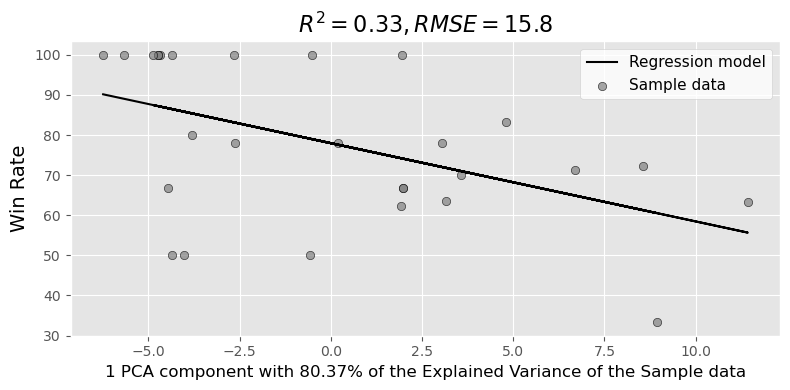

In [20]:
plt.style.use('default')
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(X_pca, y_pca_p, color='k', label='Regression model')
ax.scatter(X_pca, y, edgecolor='k', facecolor='grey', alpha=0.7, label='Sample data')
ax.set_ylabel('Win Rate', fontsize=14, color='k')
ax.set_xlabel('1 PCA component with {:.2%} of the Explained Variance of the Sample data'.format(pca.explained_variance_ratio_[0]), fontsize=12, color='k')
ax.legend(facecolor='white', fontsize=11)
ax.set_title('$R^2= {:.2f}, RMSE={:.1f}$'.format(r2, rmse) , fontsize=16)

fig.tight_layout()
fig.savefig(imgs_saving_dir+"/correlation between Win Rate and Sample data.png", dpi=600, bbox_inches='tight')

# Uni- and bi-variate models

In [21]:
from itertools import combinations


3
('#Datasets',)
(28, 1)
0.20359727368325098 17.215005201258393
0.20359727368325098 17.215005201258393
('#Baselines',)
(28, 1)
0.20916640177275858 17.154708594923946
0.20916640177275836 17.15470859492395
('#NewMethods',)
(28, 1)
0.13813041604151433 17.90859711742619
0.13813041604151433 17.90859711742619
3
('#Datasets', '#Baselines')
(28, 2)
0.2843007771362015 16.319470442525397
0.24034272401671397 16.81317139167015
('#Datasets', '#NewMethods')
(28, 2)
0.24795987057001267 16.728665488569934
0.20589849978118568 17.19011560900655
('#Baselines', '#NewMethods')
(28, 2)
0.30329843981793136 16.10142008107733
0.2137607473926303 17.104805895688283


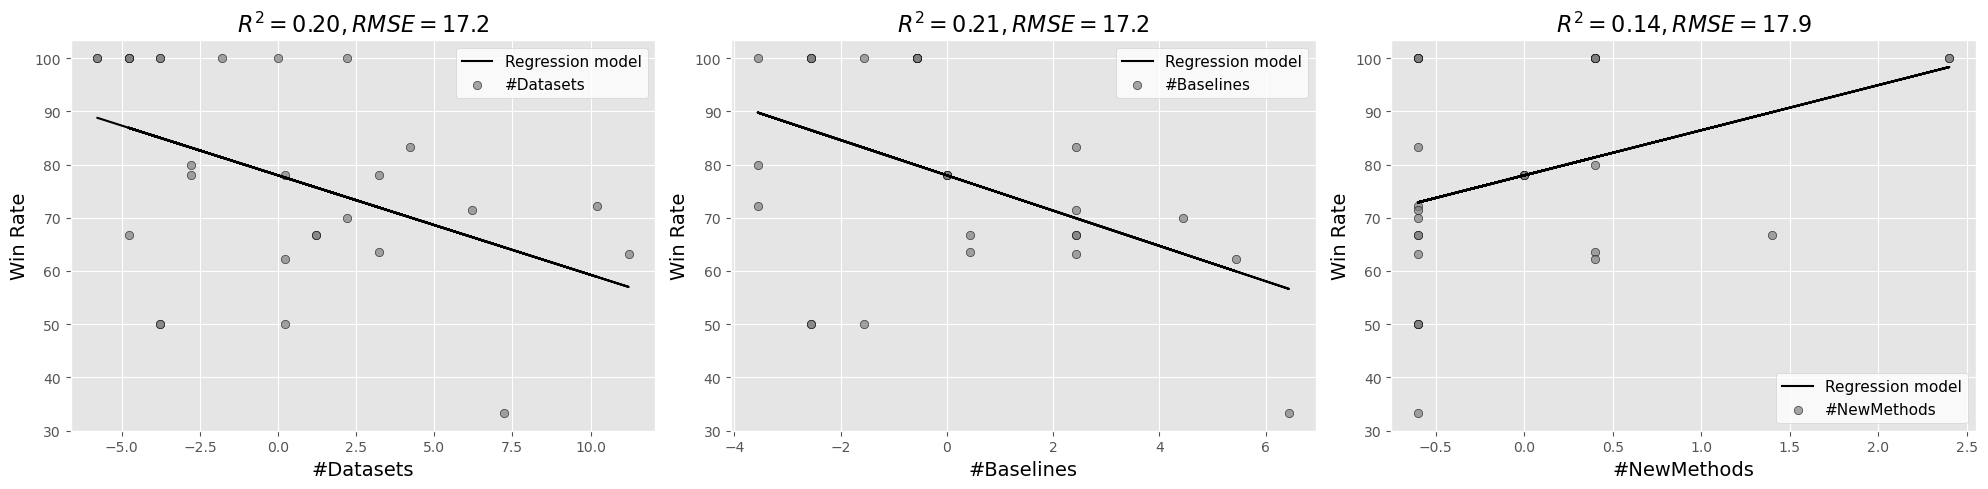

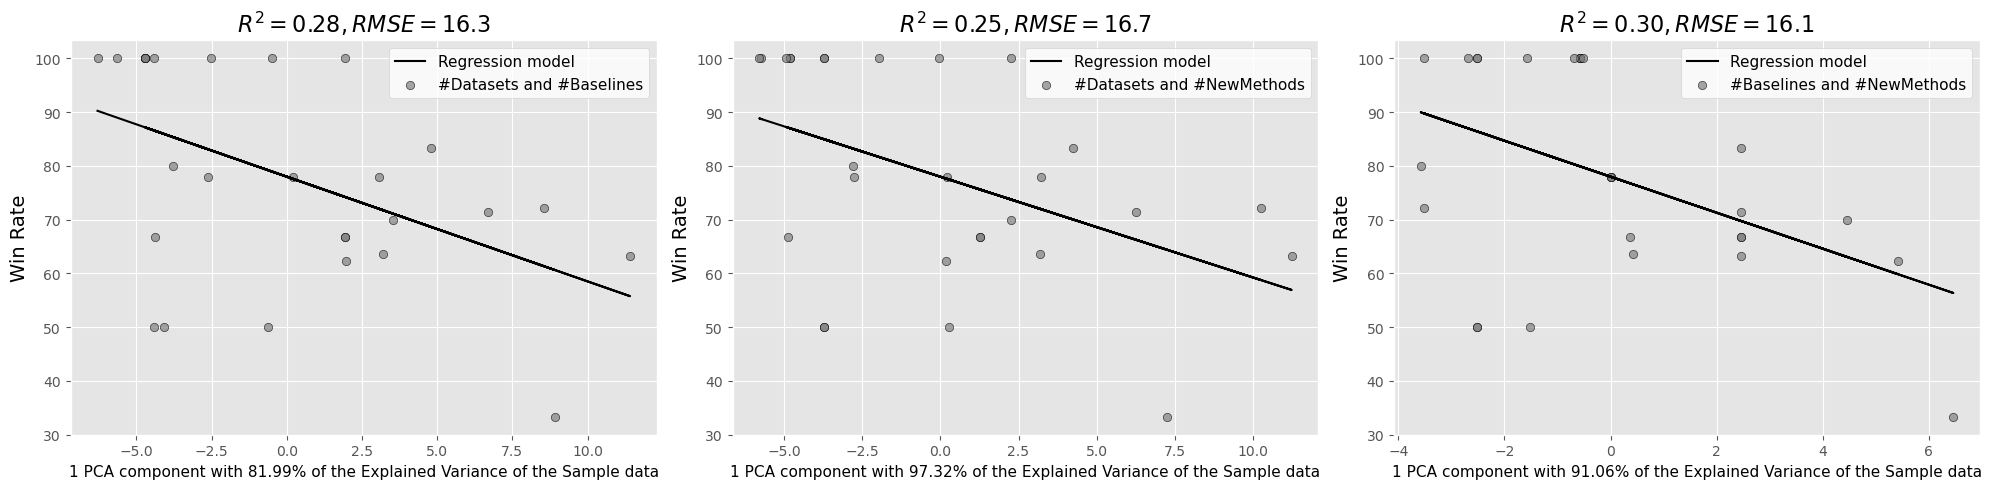

In [22]:
plt.style.use('default')
plt.style.use('ggplot')

y = df["WinRate"]

for r in range(1,3):
    cols_combination = list(combinations(df.drop("WinRate", axis=1).columns, r))
    print(len(cols_combination))
    
    fig, ax = plt.subplots(figsize=(20, 5), ncols=len(cols_combination))
    ax = ax.flatten()
    
    for i, cols in enumerate(cols_combination):
        print(cols)
        X = df.loc[:, cols]
        print(X.shape)

        # Training Linear model
        lr = LinearRegression()
        lr.fit(X, y)
        y_p = lr.predict(X)
        
        rmse = root_mean_squared_error(y, y_p) 
        r2 = lr.score(X,y)
        print(r2, rmse)

        # pca, X_pca, y_pca_p = None, None, None
        # if r>1:
        # PCA components
        pca = PCA(n_components=1)
        pca.fit(X)
        X_pca = pca.transform(X)
        # Training using PCA components
        lr_pca = LinearRegression()
        lr_pca.fit(X_pca, y)
        y_pca_p = lr_pca.predict(X_pca)
        rmse_pca = root_mean_squared_error(y, y_pca_p) 
        r2_pca =lr_pca.score(X_pca,y)
        print(r2_pca, rmse_pca)
        # else:
        #     X_pca = df[cols[0]]
        #     y_pca_p = y
            
        ax[i].plot(X_pca, y_pca_p, color='k', label='Regression model')
        label_sample_data = ' and '.join(cols) if r>1 else cols[0] #'Sample data'
        ax[i].scatter(X_pca, y, edgecolor='k', facecolor='grey', alpha=0.7, label=label_sample_data )
        ax[i].set_ylabel('Win Rate', fontsize=14, color='k')
        
        xlabel = None
        if r>1:
            xlabel = '1 PCA component with {:.2%} of the Explained Variance of the Sample data'.format(pca.explained_variance_ratio_[0])
        else:
            xlabel = cols[0]
            
        ax[i].set_xlabel(xlabel, fontsize=11 if r>1 else 14, color='k')
        ax[i].legend(facecolor='white', fontsize=11)
        ax[i].set_title('$R^2= {:.2f}, RMSE={:.1f}$'.format(r2, rmse) , fontsize=16)
        
    fig.tight_layout()
    if r==1:
        fig.savefig(imgs_saving_dir+"/univariate correlation between Win Rate and Sample data.png", dpi=600, bbox_inches='tight')
    elif r==2:
        fig.savefig(imgs_saving_dir+"/bivariate correlation between Win Rate and Sample data.png", dpi=600, bbox_inches='tight')
        